# Urban Heat Island Dataset — K-Means Clustering Analysis

## 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    calinski_harabasz_score,
    v_measure_score
)
from sklearn.decomposition import PCA

#sns.set_style('whitegrid')
#plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (8, 5)

RANDOM_STATE = 42

## 2. Load and Explore the Dataset

Update `DATA_PATH` below if your CSV is located elsewhere.

In [4]:

df=pd.read_csv(r"urbanheatisland_data.csv")
df
print("Shape:", df.shape)
df.head()

Shape: (11000, 15)


,City Name,Latitude,Longitude,Elevation (m),Temperature (°C),Land Cover,Population Density (people/km²),Energy Consumption (kWh),Air Quality Index (AQI),Urban Greenness Ratio (%),Health Impact (Mortality Rate/100k),Wind Speed (km/h),Humidity (%),Annual Rainfall (mm),GDP per Capita (USD)
0,City_1,49.312089,109.016774,240.753856,16.835175,Water,2717,16065.619101,92,28.711428,14.210173,11.382168,70.671936,1586.573011,29696.191132
1,City_2,-11.001881,-165.241523,1348.580574,21.576389,Green Space,2037,10562.356177,17,63.170980,11.259447,8.184689,64.721325,2065.057032,8105.244085
2,City_3,64.547626,136.539350,1074.991629,12.358581,Industrial,5628,25873.157659,194,1.000000,28.583728,11.963696,47.708109,1523.030958,52315.118357
3,City_4,35.526245,168.683910,218.540669,21.952336,Green Space,2116,15876.776870,37,55.920627,4.765505,14.246727,66.114209,1488.721806,20068.165345
4,City_5,-73.048077,87.176233,1780.117343,2.721762,Water,441,7413.736644,42,27.528272,19.196458,13.514924,63.050725,1823.335213,32450.104836


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 15 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   City Name                            11000 non-null  object 
 1   Latitude                             11000 non-null  float64
 2   Longitude                            11000 non-null  float64
 3   Elevation (m)                        11000 non-null  float64
 4   Temperature (°C)                     11000 non-null  float64
 5   Land Cover                           11000 non-null  object 
 6   Population Density (people/km²)      11000 non-null  int64  
 7   Energy Consumption (kWh)             11000 non-null  float64
 8   Air Quality Index (AQI)              11000 non-null  int64  
 9   Urban Greenness Ratio (%)            11000 non-null  float64
 10  Health Impact (Mortality Rate/100k)  11000 non-null  float64
 11  Wind Speed (km/h)           

In [6]:
df.describe()

,Latitude,Longitude,Elevation (m),Temperature (°C),Population Density (people/km²),Energy Consumption (kWh),Air Quality Index (AQI),Urban Greenness Ratio (%),Health Impact (Mortality Rate/100k),Wind Speed (km/h),Humidity (%),Annual Rainfall (mm),GDP per Capita (USD)
count,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000
mean,-0.262213,1.242556,698.805842,18.647807,5498.255818,22071.889004,114.716455,23.846860,19.249616,9.654599,58.440808,1507.502598,25717.113307
std,51.893576,104.260847,497.938221,9.623827,4698.867267,14075.833177,88.033338,26.245055,10.053835,5.278048,8.564187,360.936906,15354.500811
min,-89.997630,-179.993074,1.233897,-11.206956,313.000000,200.000000,5.000000,1.000000,0.500000,0.200000,26.819668,468.238183,2702.270843
25%,-45.520855,-90.341281,331.960194,10.871116,1739.000000,11211.351687,32.000000,1.000000,11.039097,5.837979,52.546508,1257.738772,15160.739627
50%,0.033474,2.690132,585.288216,18.865211,4044.000000,18157.742940,114.000000,7.996198,19.059354,9.612639,57.820400,1477.000661,21976.808977
75%,44.410728,91.888436,942.153343,26.566434,8002.000000,30334.450489,179.000000,56.435176,26.664263,13.311797,63.977220,1728.603261,31952.324564
max,89.995864,179.993696,4394.117252,41.733152,30000.000000,60000.000000,400.000000,78.515930,53.171243,29.165178,91.512761,3025.493452,120000.000000


In [7]:
# Check for missing values
df.isnull().sum()

City Name                              0
Latitude                               0
Longitude                              0
Elevation (m)                          0
Temperature (°C)                       0
Land Cover                             0
Population Density (people/km²)        0
Energy Consumption (kWh)               0
Air Quality Index (AQI)                0
Urban Greenness Ratio (%)              0
Health Impact (Mortality Rate/100k)    0
Wind Speed (km/h)                      0
Humidity (%)                           0
Annual Rainfall (mm)                   0
GDP per Capita (USD)                   0
dtype: int64

In [8]:
# Distribution of the categorical Land Cover column
df['Land Cover'].value_counts()

Land Cover
Urban          3495
Green Space    3138
Industrial     2456
Water          1911
Name: count, dtype: int64

## 3. EDA


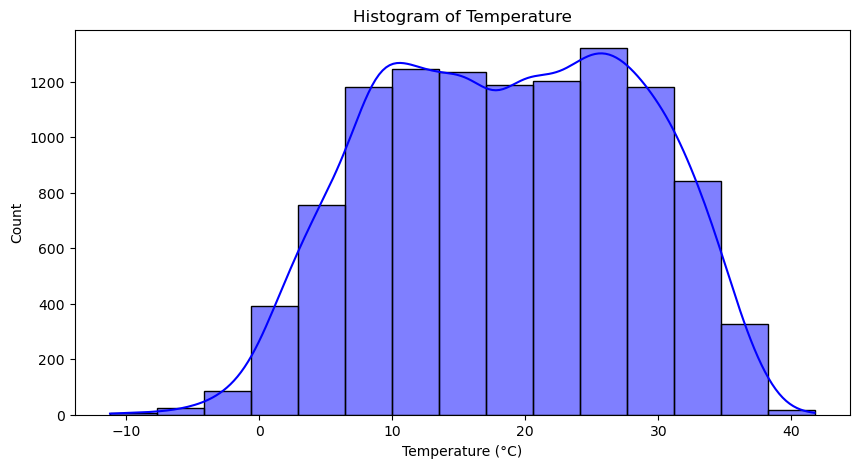

In [9]:
#Histogram of temperature
plt.figure(figsize=(10,5))
sns.histplot(df['Temperature (°C)'], bins=15, color='Blue', kde=True)  
plt.title("Histogram of Temperature")
plt.show()

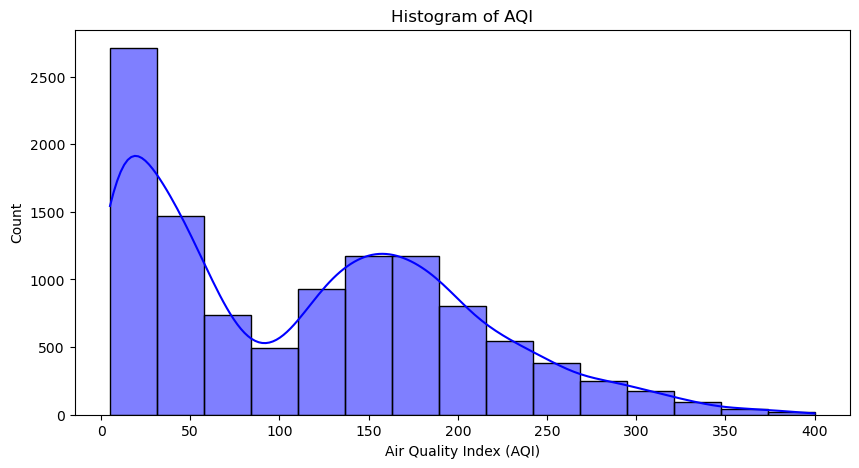

In [10]:
#Histogram of AQI
plt.figure(figsize=(10,5))
sns.histplot(df['Air Quality Index (AQI)'], bins=15, color='Blue', kde=True)  
plt.title("Histogram of AQI")
plt.show()

In [11]:
# plt.figure(figsize=(10,5))
# df['Land Cover'].value_counts().plot(kind='bar', color='lightblue')
# plt.tight_layout();
# plt.show()

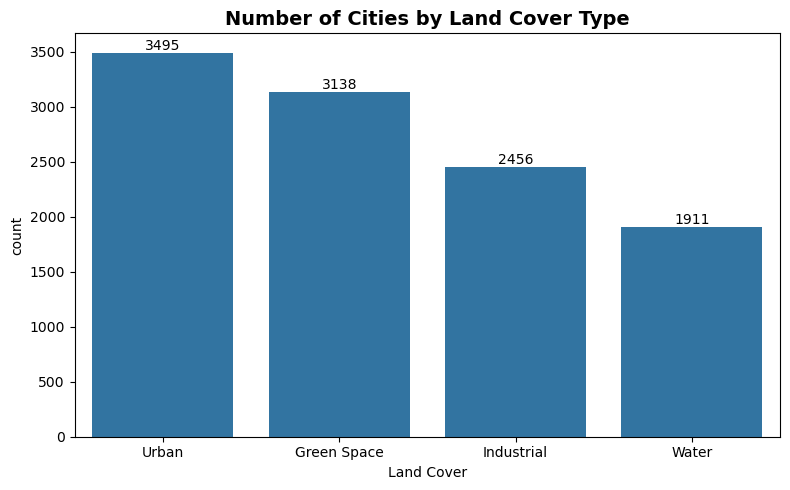

In [12]:
fig, ax = plt.subplots()
order = df['Land Cover'].value_counts().index
sns.countplot(data=df, x='Land Cover', order=order, ax=ax)
ax.set_title('Number of Cities by Land Cover Type', fontsize=14, fontweight='bold')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

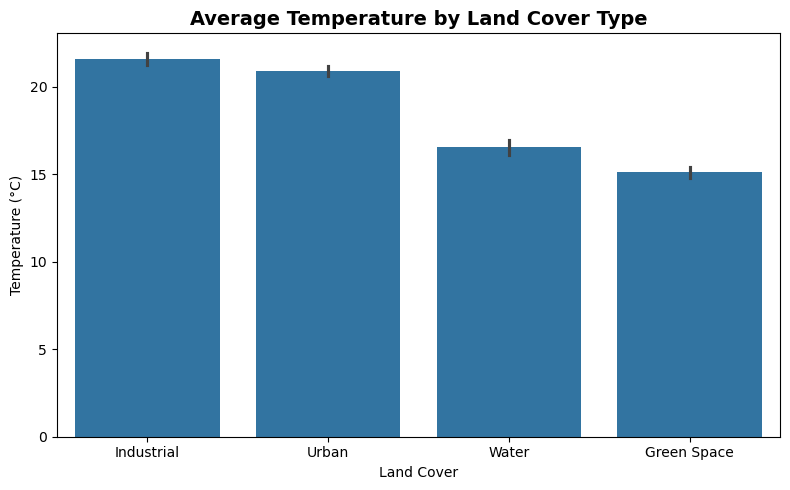

In [13]:
fig, ax = plt.subplots()
order = df.groupby('Land Cover')['Temperature (°C)'].mean().sort_values(ascending=False).index
sns.barplot(data=df, x='Land Cover', y='Temperature (°C)', order=order, estimator=np.mean, ax=ax, errorbar=('ci', 95))
ax.set_title('Average Temperature by Land Cover Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\91937\AppData\Local\Temp\ipykernel_3164\695966346.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Land Cover', y='Temperature (°C)', order=order, palette='coolwarm', ax=ax)


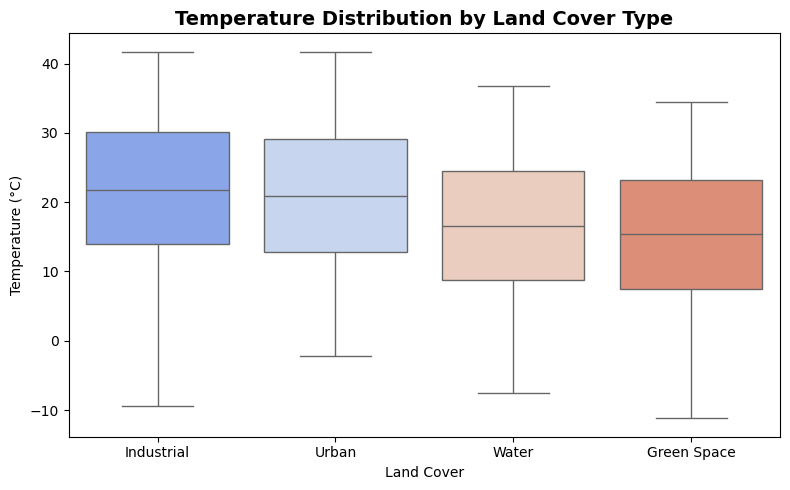

In [14]:
fig, ax = plt.subplots()
sns.boxplot(data=df, x='Land Cover', y='Temperature (°C)', order=order, palette='coolwarm', ax=ax)
ax.set_title('Temperature Distribution by Land Cover Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\91937\AppData\Local\Temp\ipykernel_3164\772879108.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Land Cover', y='Air Quality Index (AQI)', order=order_aqi, palette='magma', ax=ax)


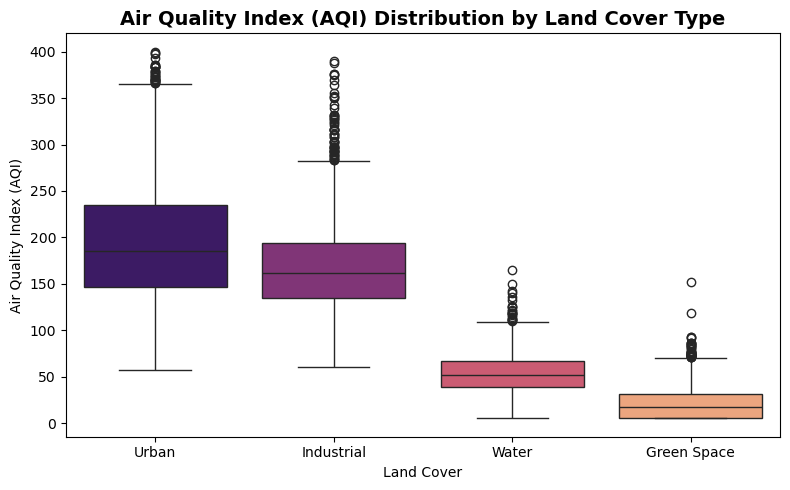

In [15]:
fig, ax = plt.subplots()
order_aqi = df.groupby('Land Cover')['Air Quality Index (AQI)'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Land Cover', y='Air Quality Index (AQI)', order=order_aqi, palette='magma', ax=ax)
ax.set_title('Air Quality Index (AQI) Distribution by Land Cover Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\91937\AppData\Local\Temp\ipykernel_3164\2566490088.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Land Cover', y='Humidity (%)', order=order, palette='crest', ax=ax)


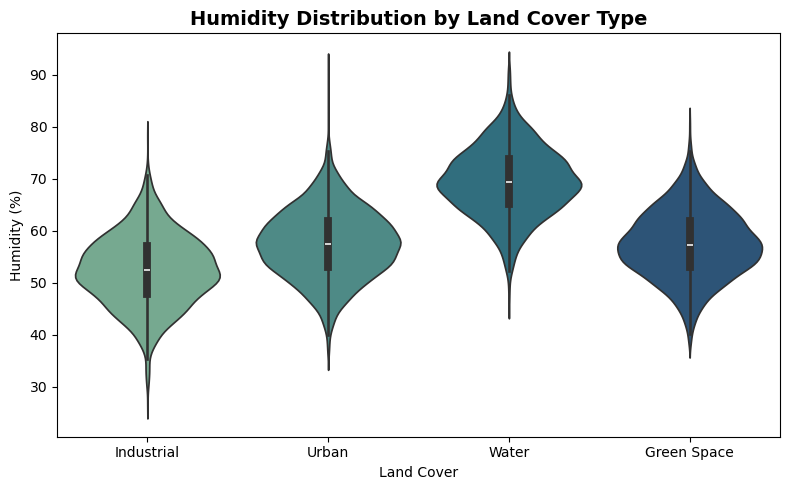

In [16]:
fig, ax = plt.subplots()
sns.violinplot(data=df, x='Land Cover', y='Humidity (%)', order=order, palette='crest', ax=ax)
ax.set_title('Humidity Distribution by Land Cover Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

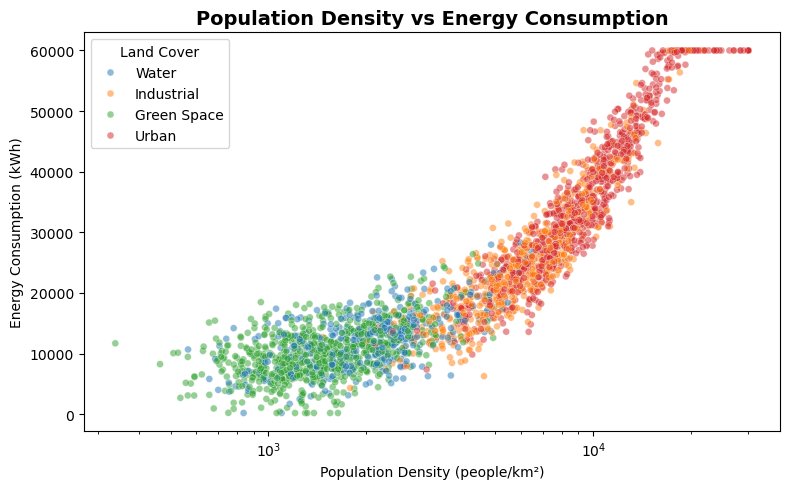

In [17]:
fig, ax = plt.subplots()
sns.scatterplot(data=df.sample(2500, random_state=42), x='Population Density (people/km²)',
                y='Energy Consumption (kWh)', hue='Land Cover', alpha=0.5, s=25, ax=ax)
ax.set_xscale('log')
ax.set_title('Population Density vs Energy Consumption', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

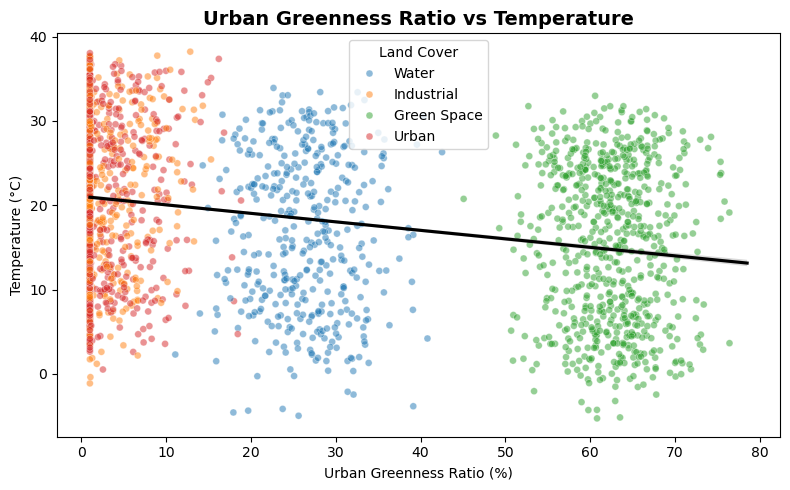

In [18]:
fig, ax = plt.subplots()
sns.scatterplot(data=df.sample(2500, random_state=42), x='Urban Greenness Ratio (%)', y='Temperature (°C)',
                hue='Land Cover', alpha=0.5, s=25, ax=ax)
sns.regplot(data=df, x='Urban Greenness Ratio (%)', y='Temperature (°C)', scatter=False, color='black', ax=ax)
ax.set_title('Urban Greenness Ratio vs Temperature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

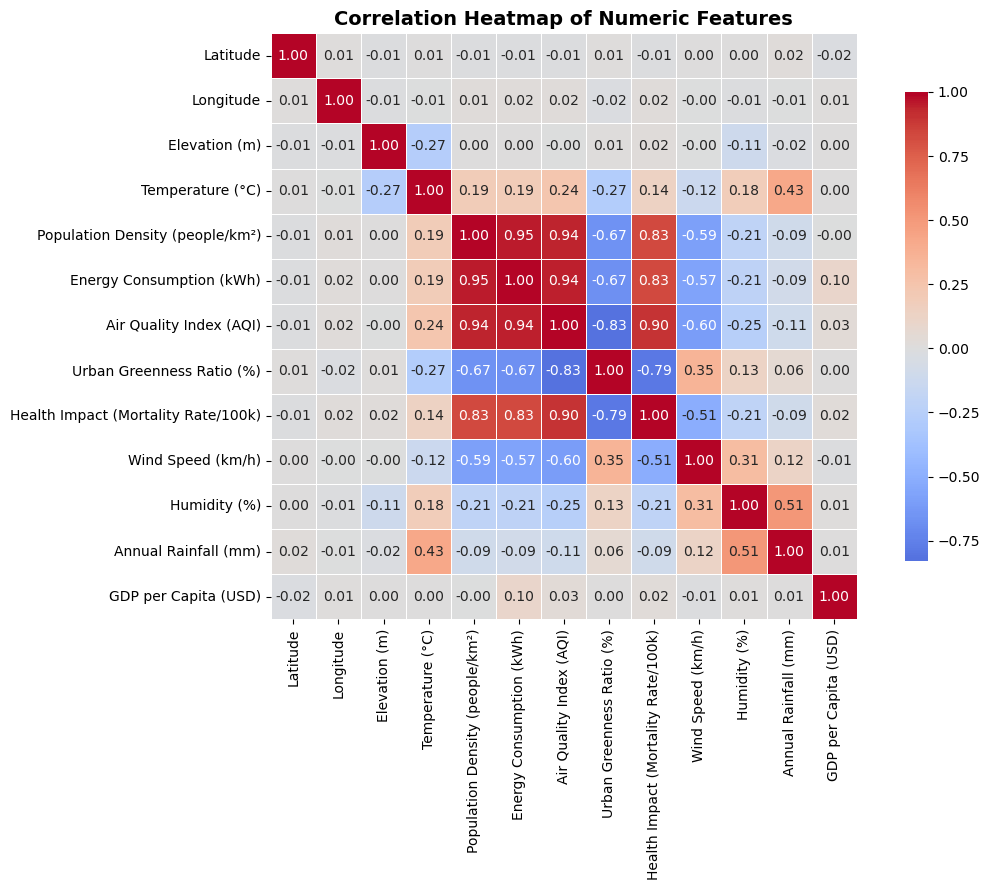

In [19]:
numeric_cols = ['Latitude', 'Longitude', 'Elevation (m)', 'Temperature (°C)',
                'Population Density (people/km²)', 'Energy Consumption (kWh)',
                'Air Quality Index (AQI)', 'Urban Greenness Ratio (%)',
                'Health Impact (Mortality Rate/100k)', 'Wind Speed (km/h)',
                'Humidity (%)', 'Annual Rainfall (mm)', 'GDP per Capita (USD)']

corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlation Heatmap of Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Feature Selection & Preprocessing

- `City Name` is an identifier and is dropped.
- `Land Cover` is a categorical column. It is **not** used as an input feature for clustering, but it is label-encoded and kept aside as ground truth to compute the **V-Measure** score (which needs true labels to compare against cluster assignments).
- All remaining numeric columns are standardized (zero mean, unit variance) since K-Means is distance-based and sensitive to feature scale.

In [20]:
feature_cols = [
    'Latitude', 'Longitude', 'Elevation (m)', 'Temperature (°C)',
    'Population Density (people/km²)', 'Energy Consumption (kWh)',
    'Air Quality Index (AQI)', 'Urban Greenness Ratio (%)',
    'Health Impact (Mortality Rate/100k)', 'Wind Speed (km/h)',
    'Humidity (%)', 'Annual Rainfall (mm)', 'GDP per Capita (USD)'
]

X = df[feature_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Ground-truth labels for V-Measure comparison only (not used to fit KMeans)
label_encoder = LabelEncoder()
true_labels = label_encoder.fit_transform(df['Land Cover'])

print("Feature matrix shape:", X_scaled.shape)
print("Land Cover classes:", list(label_encoder.classes_))

Feature matrix shape: (11000, 13)
Land Cover classes: ['Green Space', 'Industrial', 'Urban', 'Water']


## 5. Finding the Optimal Number of Clusters (k)

We sweep `k` from 2 to 10 and compute all four evaluation metrics at each step:

- **WCSS** — lower is tighter clusters (used for the elbow method)
- **Silhouette Score** — range [-1, 1], higher is better separated clusters
- **Calinski-Harabasz Score** — higher indicates denser, well-separated clusters
- **V-Measure** — range [0, 1], higher means cluster assignments align better with the true `Land Cover` categories

In [21]:
K_range = range(2, 11)
results = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)

    wcss = km.inertia_
    sil = silhouette_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    vm = v_measure_score(true_labels, labels)

    results.append({'k': k, 'WCSS': wcss, 'Silhouette': sil,
                     'CalinskiHarabasz': ch, 'VMeasure': vm})

metrics_df = pd.DataFrame(results)
metrics_df

,k,WCSS,Silhouette,CalinskiHarabasz,VMeasure
0,2,102017.148654,0.254022,4418.174649,0.559190
1,3,92258.788748,0.179858,3024.113672,0.565416
2,4,84853.254583,0.149501,2511.717193,0.545391
3,5,79939.246804,0.133706,2168.376392,0.514682
4,6,76078.198541,0.144456,1934.165739,0.481936
5,7,72829.808182,0.141190,1765.260493,0.425480
6,8,69969.188665,0.139791,1638.997681,0.482587
7,9,67510.073025,0.141513,1536.272567,0.460711
8,10,65840.554437,0.128989,1431.037350,0.448169


In [22]:
best_k_silhouette = metrics_df.loc[metrics_df['Silhouette'].idxmax(), 'k']
print(f"Best k by Silhouette Score: {int(best_k_silhouette)}")

Best k by Silhouette Score: 2


## 6. Elbow Method (WCSS vs k)

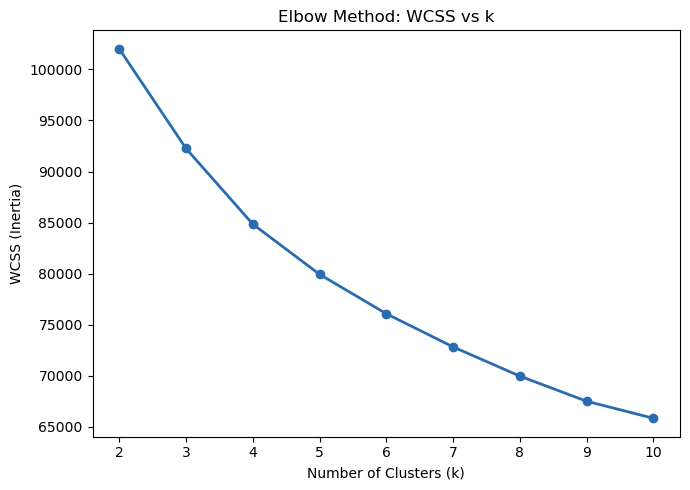

In [23]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(metrics_df['k'], metrics_df['WCSS'], marker='o', color='#2b6cb0', linewidth=2)
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('WCSS (Inertia)')
ax.set_title('Elbow Method: WCSS vs k')
ax.set_xticks(metrics_df['k'])
plt.tight_layout()
plt.show()

## 7. Silhouette Score vs k

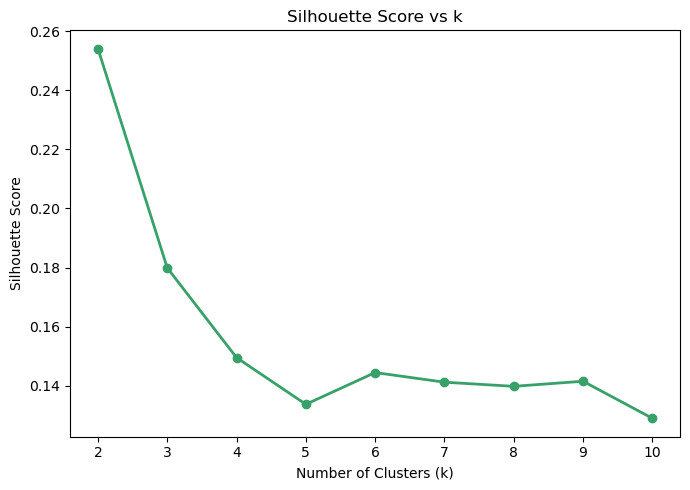

In [24]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(metrics_df['k'], metrics_df['Silhouette'], marker='o', color='#38a169', linewidth=2)
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Score vs k')
ax.set_xticks(metrics_df['k'])
plt.tight_layout()
plt.show()

## 7. Calinski-Harabasz Score vs k

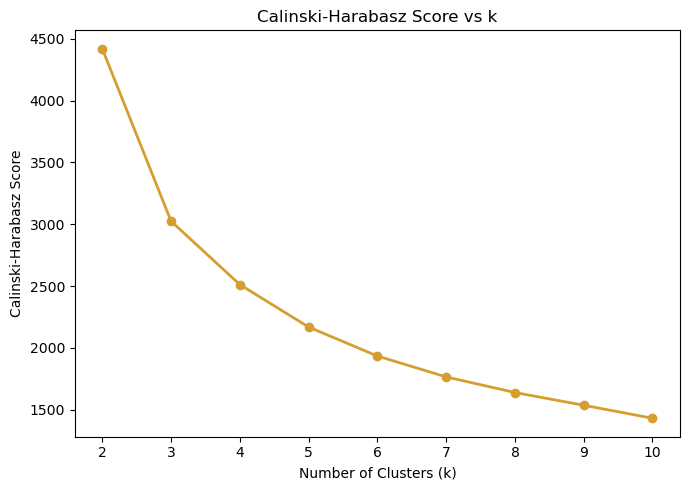

In [25]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(metrics_df['k'], metrics_df['CalinskiHarabasz'], marker='o', color='#d69e2e', linewidth=2)
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Calinski-Harabasz Score')
ax.set_title('Calinski-Harabasz Score vs k')
ax.set_xticks(metrics_df['k'])
plt.tight_layout()
plt.show()

## 8. V-Measure vs k (Cluster Assignments vs. Land Cover Ground Truth)

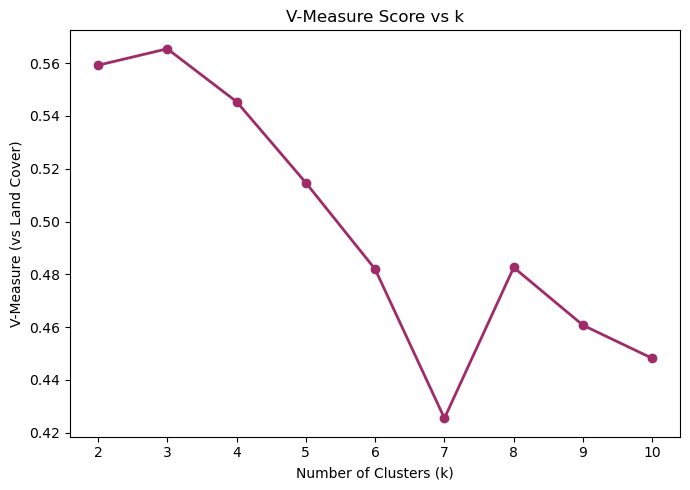

In [26]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(metrics_df['k'], metrics_df['VMeasure'], marker='o', color='#9f2b68', linewidth=2)
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('V-Measure (vs Land Cover)')
ax.set_title('V-Measure Score vs k')
ax.set_xticks(metrics_df['k'])
plt.tight_layout()
plt.show()

## 9. Fit the Final K-Means Model

We fit a final model with **k = 4**, matching the four `Land Cover` categories (Urban, Water, Green Space, Industrial), so we can meaningfully compare clusters to the ground-truth categories.

> You can change `K_FINAL` below to any value from the sweep above (e.g. the best-silhouette k) and re-run the rest of the notebook.

In [27]:
K_FINAL = 4

kmeans_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

wcss_final = kmeans_final.inertia_
sil_final = silhouette_score(X_scaled, cluster_labels)
ch_final = calinski_harabasz_score(X_scaled, cluster_labels)
vm_final = v_measure_score(true_labels, cluster_labels)

print(f"Final Model (k={K_FINAL})")
print(f"WCSS (Inertia):            {wcss_final:.2f}")
print(f"Silhouette Score:          {sil_final:.4f}")
print(f"Calinski-Harabasz Score:   {ch_final:.2f}")
print(f"V-Measure Score:           {vm_final:.4f}")

Final Model (k=4)
WCSS (Inertia):            84853.25
Silhouette Score:          0.1495
Calinski-Harabasz Score:   2511.72
V-Measure Score:           0.5454


## 10. PCA Projection — Clusters vs. True Land Cover Categories

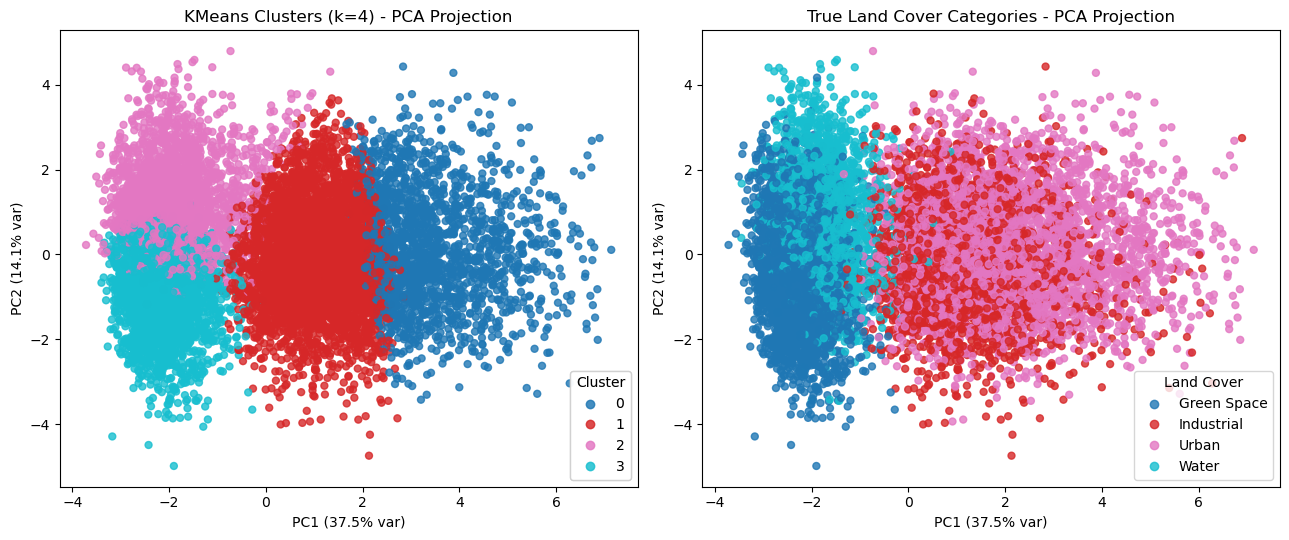

In [28]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

sc1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='tab10', s=25, alpha=0.8)
axes[0].set_title(f'KMeans Clusters (k={K_FINAL}) - PCA Projection')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
legend1 = axes[0].legend(*sc1.legend_elements(), title="Cluster", loc='best')
axes[0].add_artist(legend1)

sc2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=true_labels, cmap='tab10', s=25, alpha=0.8)
axes[1].set_title('True Land Cover Categories - PCA Projection')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
handles = sc2.legend_elements()[0]
axes[1].legend(handles, list(label_encoder.classes_), title="Land Cover", loc='best')

plt.tight_layout()
plt.show()

## 11. Per-Sample Silhouette Plot

This shows the silhouette coefficient of every individual point, grouped by cluster. Points with negative values are poorly matched to their assigned cluster.

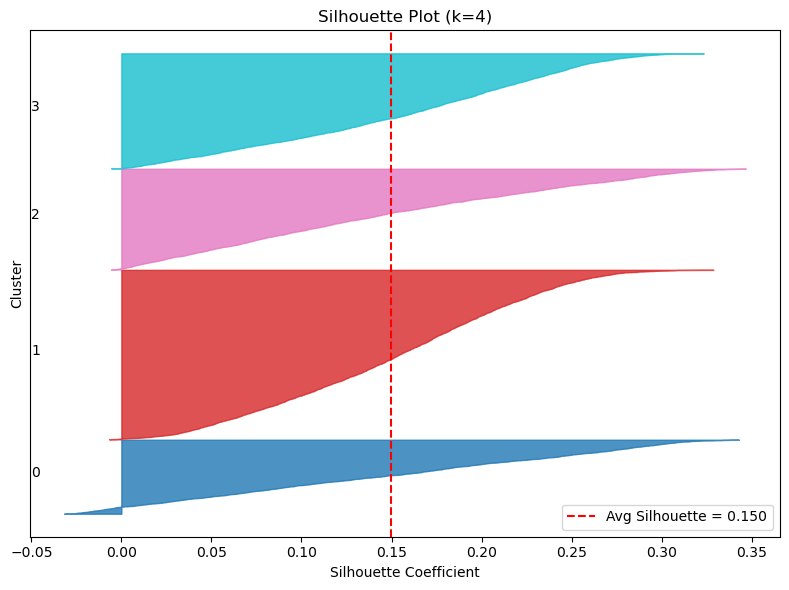

In [29]:
sample_sil_values = silhouette_samples(X_scaled, cluster_labels)

fig, ax = plt.subplots(figsize=(8, 6))
y_lower = 10
colors = plt.cm.tab10(np.linspace(0, 1, K_FINAL))

for i in range(K_FINAL):
    ith_cluster_vals = sample_sil_values[cluster_labels == i]
    ith_cluster_vals.sort()
    size_i = ith_cluster_vals.shape[0]
    y_upper = y_lower + size_i

    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_vals,
                      facecolor=colors[i], edgecolor=colors[i], alpha=0.8)
    ax.text(-0.05, y_lower + 0.5 * size_i, str(i))
    y_lower = y_upper + 10

ax.axvline(x=sil_final, color='red', linestyle='--', label=f'Avg Silhouette = {sil_final:.3f}')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.set_title(f'Silhouette Plot (k={K_FINAL})')
ax.legend()
ax.set_yticks([])
plt.tight_layout()
plt.show()

## 12. Cluster Feature Profile (Heatmap)

Mean standardized value of each feature within each cluster — useful for interpreting what characterizes each cluster (e.g. hotter/more industrial vs. cooler/greener).

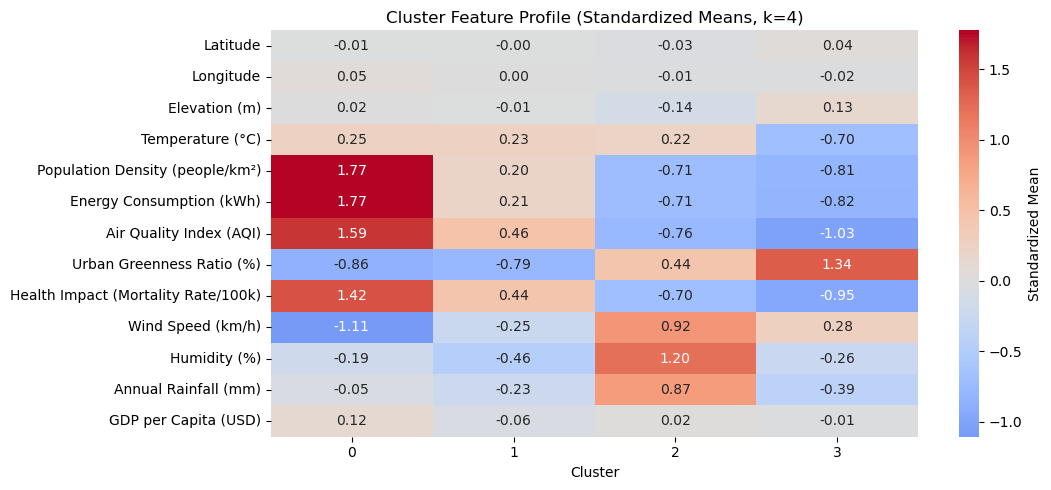

In [30]:
cluster_df = pd.DataFrame(X_scaled, columns=feature_cols)
cluster_df['Cluster'] = cluster_labels
cluster_means = cluster_df.groupby('Cluster').mean()

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(cluster_means.T, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, cbar_kws={'label': 'Standardized Mean'})
ax.set_title(f'Cluster Feature Profile (Standardized Means, k={K_FINAL})')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.show()

## 13. Land Cover vs. Cluster Crosstab

A direct comparison of how the unsupervised clusters align with the actual `Land Cover` categories.

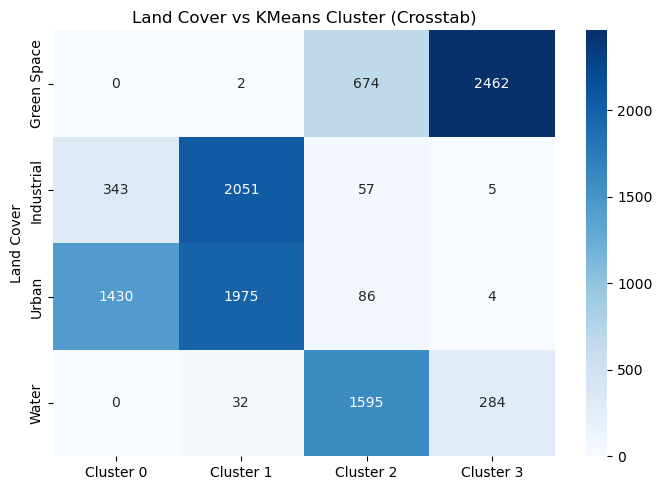

,Cluster 0,Cluster 1,Cluster 2,Cluster 3
Land Cover,,,,
Green Space,0,2,674,2462
Industrial,343,2051,57,5
Urban,1430,1975,86,4
Water,0,32,1595,284


In [31]:
crosstab = pd.crosstab(df['Land Cover'], cluster_labels)
crosstab.columns = [f'Cluster {c}' for c in crosstab.columns]

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Land Cover vs KMeans Cluster (Crosstab)')
plt.tight_layout()
plt.show()

crosstab

In [32]:
# fig, axes = plt.subplots(1, 2, figsize=(13,5.5))

# cluster_counts = df['Cluster'].value_counts().sort_index()
# axes[0].bar(cluster_counts.index.astype(str), cluster_counts.values, color=sns.color_palette('Set2', K))
# axes[0].set_title('Cluster Sizes')
# axes[0].set_xlabel('Cluster')
# axes[0].set_ylabel('Number of Cities')
# for i, v in enumerate(cluster_counts.values):
#     axes[0].text(i, v+50, str(v), ha='center')

In [33]:
cluster_counts = cluster_df['Cluster'].value_counts().sort_index()

axes[0].bar(
    cluster_counts.index.astype(str),
    cluster_counts.values,
    color=sns.color_palette("Set2")
)

axes[0].set_title("Cluster Sizes", fontsize=12)
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Number of Cities")

# Show count on top of bars
for i, value in enumerate(cluster_counts.values):
    axes[0].text(
        i,
        value + 50,
        str(value),
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

## 14. Final Metrics Summary

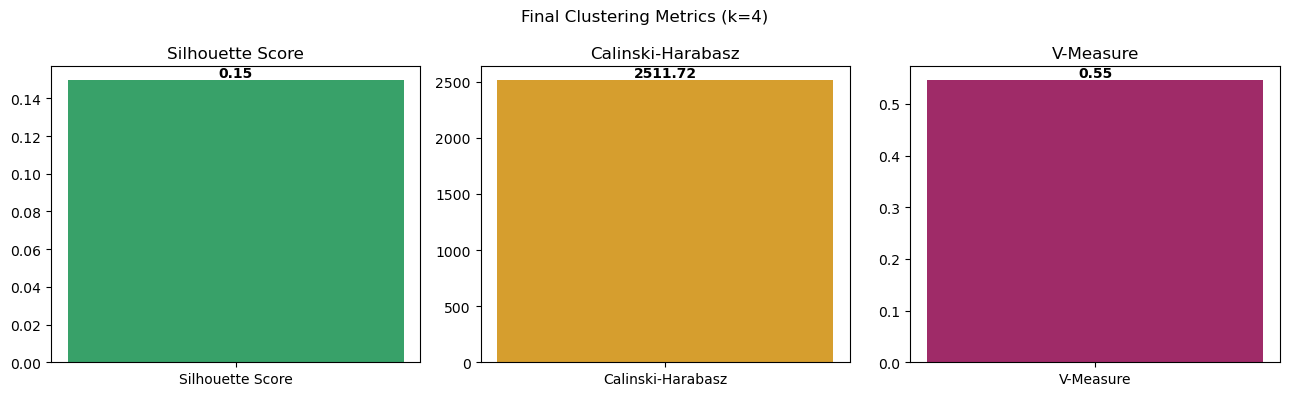

,k,WCSS,Silhouette Score,Calinski-Harabasz Score,V-Measure
0,4,84853.254583,0.149501,2511.717193,0.545391


In [34]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
metrics_names = ['Silhouette Score', 'Calinski-Harabasz', 'V-Measure']
metrics_vals = [sil_final, ch_final, vm_final]
colors_bar = ['#38a169', '#d69e2e', '#9f2b68']

for ax, name, val, c in zip(axes, metrics_names, metrics_vals, colors_bar):
    ax.bar([name], [val], color=c)
    ax.set_title(name.replace('\n', ' '))
    ax.text(0, val, f'{val:.2f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle(f'Final Clustering Metrics (k={K_FINAL})')
plt.tight_layout()
plt.show()

summary_table = pd.DataFrame([{
    'k': K_FINAL,
    'WCSS': wcss_final,
    'Silhouette Score': sil_final,
    'Calinski-Harabasz Score': ch_final,
    'V-Measure': vm_final
}])
summary_table

## 15. Save Results

Saves the metrics-by-k table, the final metrics summary, and the original dataset with cluster labels appended.

In [35]:
metrics_df.to_csv('metrics_by_k.csv', index=False)
summary_table.to_csv('final_metrics_summary.csv', index=False)

df_output = df.copy()
df_output['Cluster'] = cluster_labels
df_output.to_csv('clustered_output.csv', index=False)

print("Saved: metrics_by_k.csv, final_metrics_summary.csv, clustered_output.csv")

Saved: metrics_by_k.csv, final_metrics_summary.csv, clustered_output.csv


## 16. Conclusion

- Metrics were computed across k = 2–10 to identify the most reasonable clustering structure (elbow curve + silhouette/Calinski-Harabasz trends).
- A final model with **k = 4** was fit to align with the number of `Land Cover` categories, and evaluated using WCSS, Silhouette Score, Calinski-Harabasz Score, and V-Measure.
- Low Silhouette, Calinski-Harabasz, and V-Measure scores across all tested k values indicate that the numeric features in this dataset do **not** contain strong, well-separated natural cluster structure, and cluster assignments do not align closely with the `Land Cover` categories.
- The cluster feature heatmap and crosstab can still be used to explore what (if any) tendencies distinguish the clusters found.

**Next steps to explore:** try different feature subsets (e.g. drop latitude/longitude, or use only climate-related features), alternate algorithms (DBSCAN, Agglomerative/Hierarchical Clustering, Gaussian Mixture Models), or investigate whether the dataset is synthetic/randomly generated and thus lacks organic structure.